<a href="https://colab.research.google.com/github/tikik/HR-and-R/blob/First/r_practice_hr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

> 💡 **"Always be the first to question the data."**  
> — *CEO Alexander Wang, as noted in his latest interview*

Before delivering any analysis, **we hand-check every dataset**. This isn’t just a step — it’s a mindset. As Wang emphasized, data analysts must be more than number-pushers: they must **own the story** behind the data.

---

### ✅ Our 5-Step Hand-Check Ritual

1. **Scan for Data Integrity Issues**  
   Use `str()`, `summary()`, and missing value checks to quickly catch:
   - Typos
   - Impossible values (e.g., Age = 120)
   - Missing or inconsistent entries

2. **Hand-Check Distributions Before Modeling**  
   Visualize with boxplots, stripcharts, histograms, and density plots. Ask yourself:
   - Do these patterns make sense?
   - Are outliers real or data entry errors?

3. **Spot Suspicious or Dummy Variables**  
   Manually check for:
   - Constant columns like `StandardHours` or `EmployeeCount`
   - Columns with a single unique value that add no insight

4. **Check Consistency in Group Labels**  
   Look out for:
   - Typos in categories (e.g., `"Sales"` vs `"Sales "`)
   - Inconsistent naming conventions across columns

5. **Review a Few Random Rows by Eye**  
   Literally *look* at the data.
   - Would you be confident showing these to a client?
   - Can you explain any row without hesitation?

---

### 🔍 Why Hand-Check?

- ✅ Catch **typos and outliers** *before* your client does  
- 🧹 Avoid modeling with **garbage variables**  
- 🧠 Turn **strange patterns into explained stories**, not surprises  

---

### 🧭 Final Tip:

> When in doubt, assume your client will ask:  
> “**Can you explain this number to me?**”  
> — and you should be able to say **yes**, confidently.


In [1]:
install.packages(c("tidyverse", "DataExplorer", "skimr", "corrplot"))
library(tidyverse)
library(DataExplorer)
library(skimr)
library(corrplot)

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘plyr’, ‘igraph’, ‘reshape2’, ‘gridExtra’, ‘networkD3’


── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.4     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded



#### Side note: I use google colab for this analysis out of curiosity, also they offer vega.js collaboration with html/css but it has been very slow. Everytime I have to reupload dataset, another option is to mount the notebook to the file location on google drive, but process is super slow.

Dont want to download too many randonm packages like, readr?


In [13]:
hrdata <- readr::read_csv("/hr.csv.csv")

Rows: 1470 Columns: 35
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr  (9): Attrition, BusinessTravel, Department, EducationField, Gender, Job...
dbl (26): Age, DailyRate, DistanceFromHome, Education, EmployeeCount, Employ...

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [11]:
# Skimming through this dataset, this time we load readr
library(readr)
hrdata <- read.csv("/hr.csv.csv")
str(hrdata)
head(hrdata)
glimpse(hrdata)

'data.frame':	1470 obs. of  35 variables:
 $ Age                     : int  41 49 37 33 27 32 59 30 38 36 ...
 $ Attrition               : chr  "Yes" "No" "Yes" "No" ...
 $ BusinessTravel          : chr  "Travel_Rarely" "Travel_Frequently" "Travel_Rarely" "Travel_Frequently" ...
 $ DailyRate               : int  1102 279 1373 1392 591 1005 1324 1358 216 1299 ...
 $ Department              : chr  "Sales" "Research & Development" "Research & Development" "Research & Development" ...
 $ DistanceFromHome        : int  1 8 2 3 2 2 3 24 23 27 ...
 $ Education               : int  2 1 2 4 1 2 3 1 3 3 ...
 $ EducationField          : chr  "Life Sciences" "Life Sciences" "Other" "Life Sciences" ...
 $ EmployeeCount           : int  1 1 1 1 1 1 1 1 1 1 ...
 $ EmployeeNumber          : int  1 2 4 5 7 8 10 11 12 13 ...
 $ EnvironmentSatisfaction : int  2 3 4 4 1 4 3 4 4 3 ...
 $ Gender                  : chr  "Female" "Male" "Male" "Female" ...
 $ HourlyRate              : int  94 61 92 56 40 79 8

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
,<int>,<chr>,<chr>,<int>,<chr>,<int>,<int>,<chr>,<int>,<int>,⋯,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
1,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,⋯,1,80,0,8,0,1,6,4,0,5
2,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,⋯,4,80,1,10,3,3,10,7,1,7
3,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,⋯,2,80,0,7,3,3,0,0,0,0
4,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,⋯,3,80,0,8,3,3,8,7,3,0
5,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,⋯,4,80,1,6,3,3,2,2,2,2
6,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,⋯,3,80,0,8,2,2,7,7,3,6


Rows: 1,470
Columns: 35
$ Age                      <int> 41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 2…
$ Attrition                <chr> "Yes", "No", "Yes", "No", "No", "No", "No", "…
$ BusinessTravel           <chr> "Travel_Rarely", "Travel_Frequently", "Travel…
$ DailyRate                <int> 1102, 279, 1373, 1392, 591, 1005, 1324, 1358,…
$ Department               <chr> "Sales", "Research & Development", "Research …
$ DistanceFromHome         <int> 1, 8, 2, 3, 2, 2, 3, 24, 23, 27, 16, 15, 26, …
$ Education                <int> 2, 1, 2, 4, 1, 2, 3, 1, 3, 3, 3, 2, 1, 2, 3, …
$ EducationField           <chr> "Life Sciences", "Life Sciences", "Other", "L…
$ EmployeeCount            <int> 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, …
$ EmployeeNumber           <int> 1, 2, 4, 5, 7, 8, 10, 11, 12, 13, 14, 15, 16,…
$ EnvironmentSatisfaction  <int> 2, 3, 4, 4, 1, 4, 3, 4, 4, 3, 1, 4, 1, 2, 3, …
$ Gender                   <chr> "Female", "Male", "Male", "Female", "Male", "…
$ HourlyRate    

In [14]:
class(hrdata)
ncol(hrdata)
nrow(hrdata)
#Checking for missing data?
test_complete <- complete.cases(hrdata)
#what type of data is the result from above command
class(test_complete) # Should be "logical"
length(test_complete) # Should be equal to nrow(hrdata)
rows_with_missing_values <- hrdata[!complete.cases(hrdata), ]
print(rows_with_missing_values)

[1] "spec_tbl_df" "tbl_df"      "tbl"         "data.frame"

[1] 35

[1] 1470

[1] "logical"

[1] 1470

# A tibble: 0 × 35
# ℹ 35 variables: Age <dbl>, Attrition <chr>, BusinessTravel <chr>,
#   DailyRate <dbl>, Department <chr>, DistanceFromHome <dbl>, Education <dbl>,
#   EducationField <chr>, EmployeeCount <dbl>, EmployeeNumber <dbl>,
#   EnvironmentSatisfaction <dbl>, Gender <chr>, HourlyRate <dbl>,
#   JobInvolvement <dbl>, JobLevel <dbl>, JobRole <chr>, JobSatisfaction <dbl>,
#   MaritalStatus <chr>, MonthlyIncome <dbl>, MonthlyRate <dbl>,
#   NumCompaniesWorked <dbl>, Over18 <chr>, OverTime <chr>, …


In [15]:
colSums(is.na(hrdata))


Age                Attrition           BusinessTravel 
                       0                        0                        0 
               DailyRate               Department         DistanceFromHome 
                       0                        0                        0 
               Education           EducationField            EmployeeCount 
                       0                        0                        0 
          EmployeeNumber  EnvironmentSatisfaction                   Gender 
                       0                        0                        0 
              HourlyRate           JobInvolvement                 JobLevel 
                       0                        0                        0 
                 JobRole          JobSatisfaction            MaritalStatus 
                       0                        0                        0 
           MonthlyIncome              MonthlyRate       NumCompaniesWorked 
                       0                        0                        0 
                  Over18                 OverTime        PercentSalaryHike 
                       0                        0                        0 
       PerformanceRating RelationshipSatisfaction            StandardHours 
                       0                        0                        0 
        StockOptionLevel        TotalWorkingYears    TrainingTimesLastYear 
                       0                        0                        0 
         WorkLifeBalance           YearsAtCompany       YearsInCurrentRole 
                       0                        0                        0 
 YearsSinceLastPromotion     YearsWithCurrManager 
                       0                        0

In [16]:
sum(is.na(hrdata))


[1] 0

Lets circle back to Prob and Stat:
*  Why do we need thresholds? Why do we need hypotheses?

Because we’re human — and humans naturally compare.
We wonder if the grass is greener on the other hill.
We compare ourselves, our ideas, our cities — almost instinctively.

Science is no different. Curiosity drives us to ask questions. But instead of vague comparisons, we need structure.
We create a baseline — a reference point — to decide whether what we’re seeing is unusual or meaningful.

That’s what a hypothesis is: a starting claim, a point of comparison. It’s just like how we call Denver the Mile High City — not because we guessed, but because we measured its height compared to sea level.
And the threshold — like a 5% significance level — tells us how surprising our result needs to be before we say, “Okay, that’s probably not just random.”
An analogy to remember: the magician says he has a fair dice, but when he rolled it for 6 times, it rolled on the six side back to back. Then probbility for this event to occur is: (1/6)^ 6 =. This still happens. Thus it meant it is so rare and it still happeneded? Then I started to doubt if the magician lies, or we reject the null hypothesis that the dice is a fair one. In this case, we pick 5% to be the threshold or point of beginning like threshold of the y2k era, like we start to see something different at that number.

*  But we Can Choose a Different Threshold. We Use 0.5% (0.005) if:
You want to be much more cautious about drawing conclusions.The consequences of a false positive are serious (e.g., approving a dangerous drug). Or we want stronger evidence before saying something is significant.
*  We Use 10% (0.10) if: You’re in an exploratory study where missing something might be worse than a false positive. You’re okay with more uncertainty and want to be more inclusive of borderline results.






In order to plan for: Succession planning, Mentoring program design, Retirement risk detection, we need to see this plot.

Also, In a density plot created with geom_density() in ggplot2, the y-axis represents probability density/  The height of the curve at a given x (e.g. age = 30) tells you how dense the data is around that value. Thus, it’s essentially answering: “What is the relative likelihood of seeing an employee around this age?

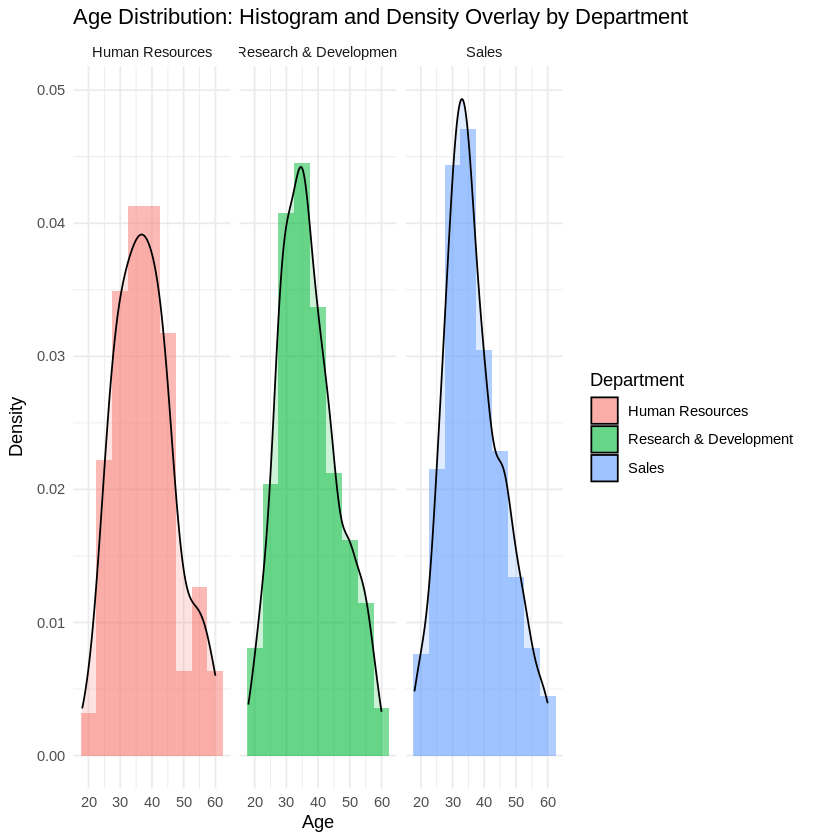

In [17]:
ggplot(hrdata, aes(x = Age, fill = Department)) +
  geom_histogram(aes(y = after_stat(density)),      # histogram scaled to density
                 binwidth = 5,              # adjust bin width as needed
                 alpha = 0.5,               # make bars semi-transparent
                 position = position_dodge(width = 6)) +   # bars overlap, not stacked
  geom_density(alpha = 0.2) +                # smooth density curve with some transparency
  facet_wrap(~ Department) +                  # separate panel per department
  labs(title = "Age Distribution: Histogram and Density Overlay by Department",
       y = "Density") +
  theme_minimal()

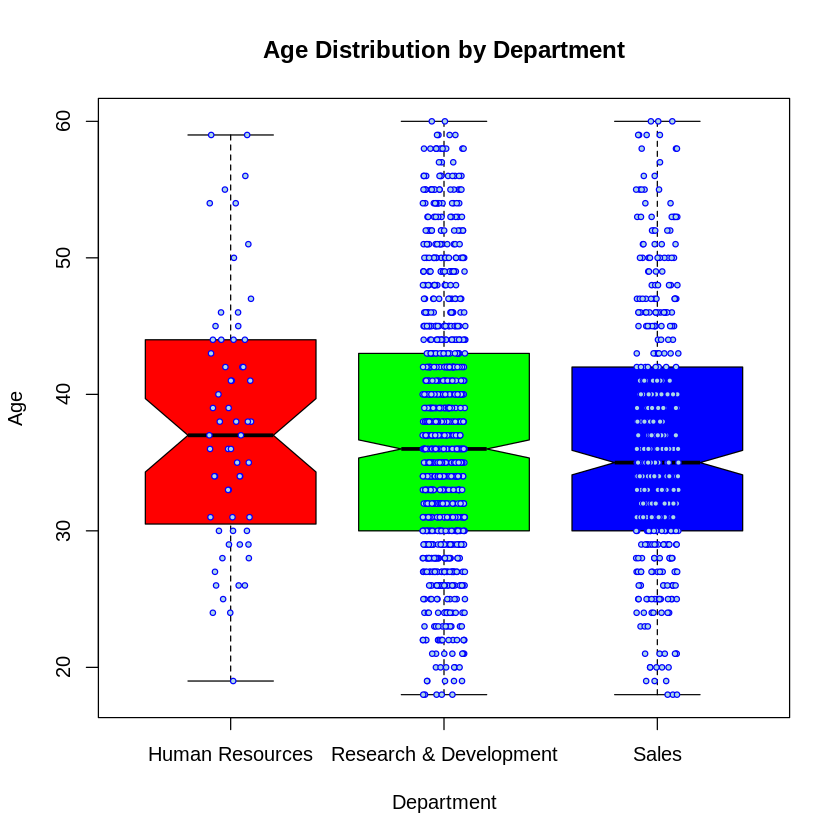

In [18]:
boxplot(Age ~ Department, data = hrdata,
        main = "Age Distribution by Department",
        xlab = "Department",
        ylab = "Age",
        col = rainbow(length(unique(hrdata$Department))),
        notch = TRUE)  # notch adds confidence interval around median
stripchart(Age ~ Department, data = hrdata,
           vertical = TRUE,
           method = "jitter",
           add = TRUE,
           pch = 21,
           col = 'blue',
           bg = 'lightblue',
           cex = 0.6)

## How to Decide Which Outliers to Look For in a Large Dataset

With 24 columns in your HR dataset, the question “Which outliers should I look for?” is very important. Outliers are unusual values that stand out and might affect your analysis or models.

---

### 1. Focus on Numeric Variables Relevant to Your Question

Outliers usually make sense to check in **numeric columns** where extreme values can skew results or indicate data errors. Examples in your dataset include:

- Age  
- DailyRate  
- DistanceFromHome  
- HourlyRate  
- MonthlyIncome  
- MonthlyRate  
- NumCompaniesWorked  
- PercentSalaryHike  
- TotalWorkingYears  
- TrainingTimesLastYear  
- YearsAtCompany  
- YearsInCurrentRole  
- YearsSinceLastPromotion  
- YearsWithCurrManager  

---

### 2. Choose Variables Most Impactful to Your Analysis

If you’re analyzing **employee attrition** or **performance**, variables like:

- MonthlyIncome  
- YearsAtCompany  
- TotalWorkingYears  
- PercentSalaryHike  

might be particularly important to check for outliers.

---

### 3. Check for Outliers in Predictor and Outcome Variables

- If you plan to **model attrition**, look at outliers in:  
  - Predictors (like `MonthlyIncome`)  
  - Outcome variables (`Attrition` is categorical but sometimes linked with numeric ones)  

---

### 4. Look at Multivariate Outliers

- Sometimes a combination of variables together can be unusual even if each variable alone looks fine.  
- Techniques like **Mahalanobis distance** or **clustering** can help detect these but are more advanced.

---

### Quick Example: How to Check Outliers Across Multiple Numeric Columns

Here’s a snippet to quickly summarize outliers in several numeric columns using the IQR method:



In [19]:
numeric_cols <- c("Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome",
                  "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears",
                  "TrainingTimesLastYear", "YearsAtCompany", "YearsInCurrentRole",
                  "YearsSinceLastPromotion", "YearsWithCurrManager")

outlier_summary <- sapply(hrdata[numeric_cols], function(x) {
  qnt <- quantile(x, probs=c(.25, .75), na.rm=TRUE)
  H <- 1.5 * IQR(x, na.rm=TRUE)
  sum(x < (qnt[1] - H) | x > (qnt[2] + H), na.rm=TRUE)
})

print(outlier_summary)

                    Age               DailyRate        DistanceFromHome 
                      0                       0                       0 
             HourlyRate           MonthlyIncome             MonthlyRate 
                      0                     114                       0 
     NumCompaniesWorked       PercentSalaryHike       TotalWorkingYears 
                     52                       0                      63 
  TrainingTimesLastYear          YearsAtCompany      YearsInCurrentRole 
                    238                     104                      21 
YearsSinceLastPromotion    YearsWithCurrManager 
                    107                      14 


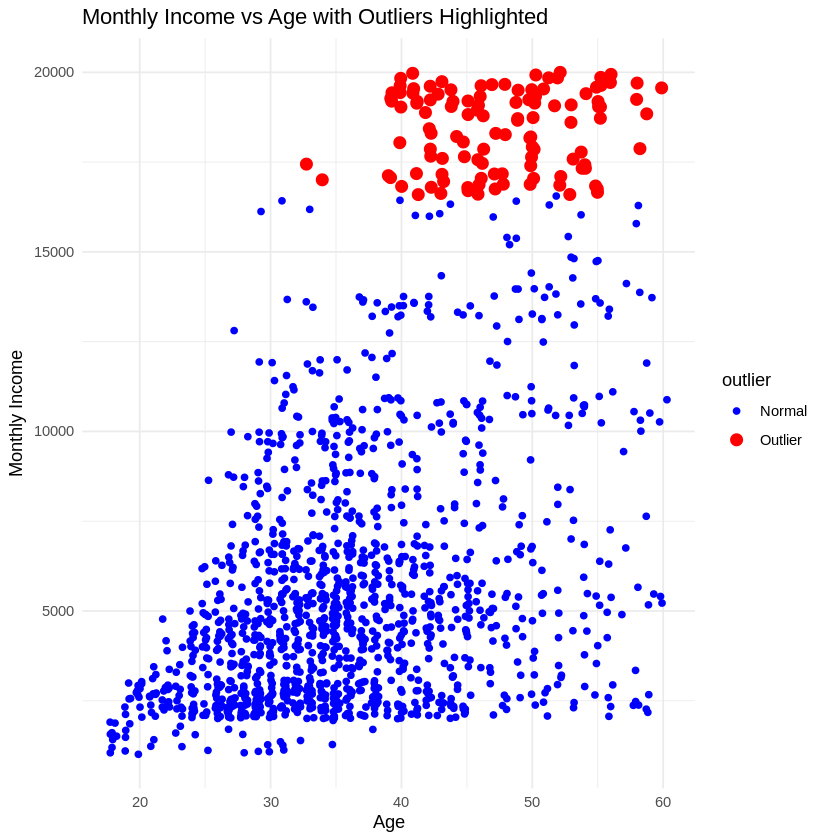

In [20]:
# Example: Using the HR dataset, let's say we want to plot MonthlyIncome vs Age
# and highlight outliers in MonthlyIncome

# Define outliers as points beyond 1.5 * IQR (common rule)
iqr <- IQR(hrdata$MonthlyIncome, na.rm = TRUE)
q1 <- quantile(hrdata$MonthlyIncome, 0.25, na.rm = TRUE)
q3 <- quantile(hrdata$MonthlyIncome, 0.75, na.rm = TRUE)
lower_bound <- q1 - 1.5 * iqr
upper_bound <- q3 + 1.5 * iqr

# Create a new column indicating outliers
hrdata$outlier <- ifelse(hrdata$MonthlyIncome < lower_bound | hrdata$MonthlyIncome > upper_bound, "Outlier", "Normal")

# Plot with jitter, color and size by outlier status
ggplot(hrdata, aes(x = Age, y = MonthlyIncome, color = outlier, size = outlier)) +
  geom_jitter(width = 0.3, height = 0) +
  scale_color_manual(values = c("Normal" = "blue", "Outlier" = "red")) +
  scale_size_manual(values = c("Normal" = 1.5, "Outlier" = 3)) +
  theme_minimal() +
  labs(title = "Monthly Income vs Age with Outliers Highlighted",
       x = "Age",
       y = "Monthly Income")



## Now we are looking at multiple columns with outlier altogether:

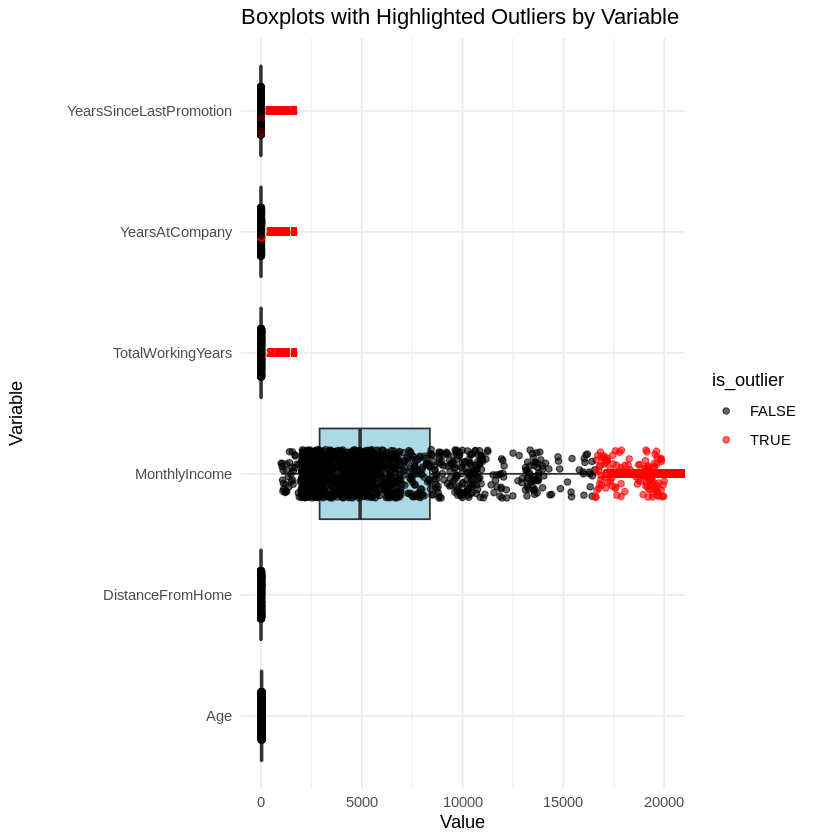

In [21]:
# Select numeric columns and add ID to trace back (like EmployeeNumber)
library(dplyr)
library(tidyr)
library(ggplot2)
numeric_cols <- c("EmployeeNumber", "Age", "MonthlyIncome", "DistanceFromHome",
                  "TotalWorkingYears", "YearsAtCompany", "YearsSinceLastPromotion")

# Subset and pivot longer
hr_long <- hrdata %>%
  select(all_of(numeric_cols)) %>%
  pivot_longer(-EmployeeNumber, names_to = "Variable", values_to = "Value")

# Compute outlier thresholds (IQR rule)
hr_outliers <- hr_long %>%
  group_by(Variable) %>%
  mutate(
    Q1 = quantile(Value, 0.25, na.rm = TRUE),
    Q3 = quantile(Value, 0.75, na.rm = TRUE),
    IQR = Q3 - Q1,
    is_outlier = Value < (Q1 - 1.5 * IQR) | Value > (Q3 + 1.5 * IQR)
  )

# Plot with outliers highlighted and labeled
ggplot(hr_outliers, aes(x = Variable, y = Value)) +
  geom_boxplot(outlier.shape = NA, fill = "lightblue") +
  geom_jitter(aes(color = is_outlier), width = 0.2, size = 1.5, alpha = 0.6) +
  geom_text(data = filter(hr_outliers, is_outlier),
            aes(label = EmployeeNumber), hjust = -0.3, size = 2.5, color = "red") +
  coord_flip() +
  labs(title = "Boxplots with Highlighted Outliers by Variable",
       y = "Value", x = "Variable") +
  scale_color_manual(values = c("FALSE" = "black", "TRUE" = "red")) +
  theme_minimal()

## Or a side by side comparison:

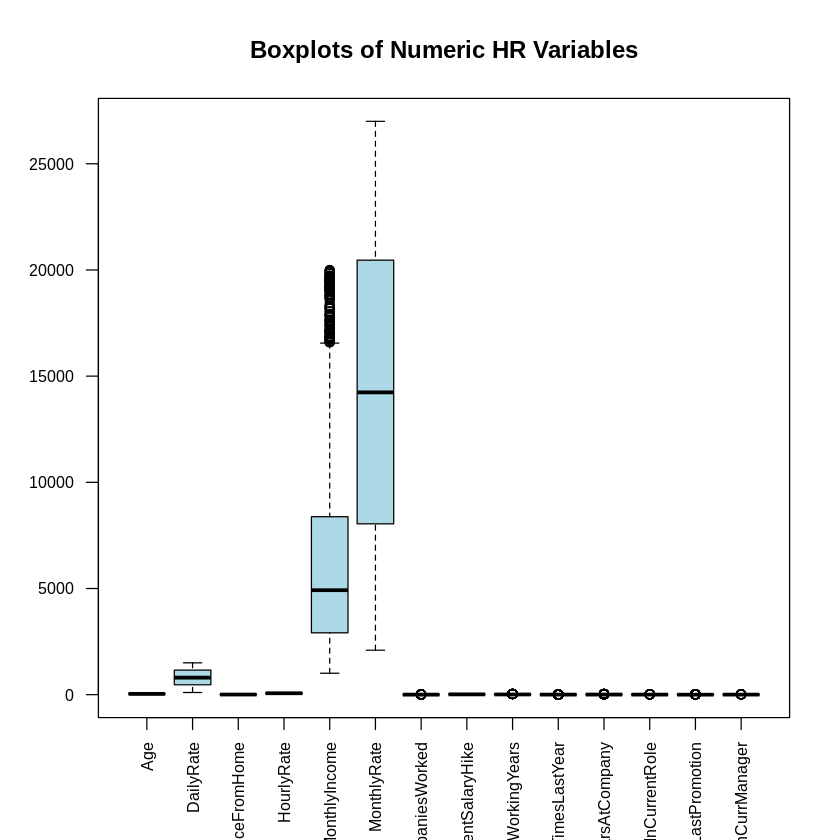

In [22]:
# Select numeric columns
numeric_cols <- c("Age", "DailyRate", "DistanceFromHome", "HourlyRate", "MonthlyIncome",
                  "MonthlyRate", "NumCompaniesWorked", "PercentSalaryHike", "TotalWorkingYears",
                  "TrainingTimesLastYear", "YearsAtCompany", "YearsInCurrentRole",
                  "YearsSinceLastPromotion", "YearsWithCurrManager")

# Create side-by-side boxplots
boxplot(hrdata[numeric_cols],
        main = "Boxplots of Numeric HR Variables",
        las = 2,         # rotate x-axis labels
        col = "lightblue",
        outline = TRUE,  # show outliers
        cex.axis = 0.8)  # shrink axis labels


In [23]:
# prompt: What are the outlier values here, make a new dataframe for this

outliers_df <- hr_outliers %>%
  filter(is_outlier) %>%
  select(EmployeeNumber, Variable, Value)

outliers_df

EmployeeNumber,Variable,Value
<dbl>,<chr>,<dbl>
20,YearsSinceLastPromotion,8
23,TotalWorkingYears,31
23,YearsAtCompany,25
32,MonthlyIncome,19094
36,YearsAtCompany,22
38,MonthlyIncome,18947
58,MonthlyIncome,19545
58,YearsAtCompany,22
58,YearsSinceLastPromotion,15


[1] "Original number of rows: 1470"
[1] "Number of rows after removing MonthlyIncome outliers: 1356"
[1] "Number of rows after removing employees with any selected outlier: 1235"


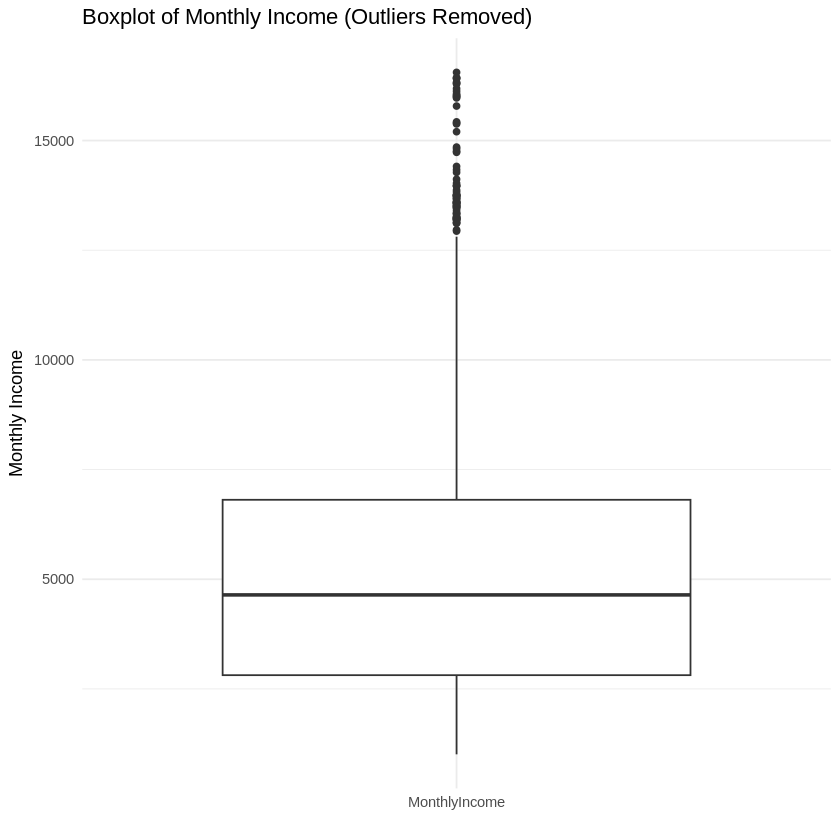

In [37]:
# prompt: create a copy of data frame when removing outliers

# Create a new dataframe `hrdata_no_outliers` by filtering out rows where MonthlyIncome is an outlier
hrdata_no_outliers <- hrdata %>%
  filter(outlier == "Normal")

# Verify the size of the new dataframe
print(paste("Original number of rows:", nrow(hrdata)))
print(paste("Number of rows after removing MonthlyIncome outliers:", nrow(hrdata_no_outliers)))

# Optionally, check the boxplot for MonthlyIncome in the new dataframe
ggplot(hrdata_no_outliers, aes(x = "MonthlyIncome", y = MonthlyIncome)) +
  geom_boxplot() +
  theme_minimal() +
  labs(title = "Boxplot of Monthly Income (Outliers Removed)",
       x = "",
       y = "Monthly Income")

# To remove outliers from *all* selected numeric columns simultaneously (more complex and depends on method)
# Using the hr_outliers dataframe created previously, filter out rows where *any* of the selected variables are outliers for that employee number
employee_numbers_with_outliers <- hr_outliers %>%
  filter(is_outlier) %>%
  distinct(EmployeeNumber) %>%
  pull(EmployeeNumber)

hrdata_cleaned <- hrdata %>%
  filter(!EmployeeNumber %in% employee_numbers_with_outliers)

print(paste("Number of rows after removing employees with any selected outlier:", nrow(hrdata_cleaned)))

In [24]:
cor(hrdata[, c("Age", "DailyRate", "DistanceFromHome", "Education", "HourlyRate", "MonthlyIncome", "MonthlyRate", "NumCompaniesWorked", "TotalWorkingYears", "TrainingTimesLastYear")])

,Age,DailyRate,DistanceFromHome,Education,HourlyRate,MonthlyIncome,MonthlyRate,NumCompaniesWorked,TotalWorkingYears,TrainingTimesLastYear
Age,1.00000000,0.010660943,-0.001686120,0.20803373,0.024286543,0.497854567,0.028051167,0.29963476,0.680380536,-0.019620819
DailyRate,0.01066094,1.000000000,-0.004985337,-0.01680643,0.023381422,0.007707059,-0.032181602,0.03815343,0.014514739,0.002452543
DistanceFromHome,-0.00168612,-0.004985337,1.000000000,0.02104183,0.031130586,-0.017014445,0.027472864,-0.02925080,0.004628426,-0.036942234
Education,0.20803373,-0.016806433,0.021041826,1.00000000,0.016774829,0.094960677,-0.026084197,0.12631656,0.148279697,-0.025100241
HourlyRate,0.02428654,0.023381422,0.031130586,0.01677483,1.000000000,-0.015794304,-0.015296750,0.02215688,-0.002333682,-0.008547685
MonthlyIncome,0.49785457,0.007707059,-0.017014445,0.09496068,-0.015794304,1.000000000,0.034813626,0.14951522,0.772893246,-0.021736277
MonthlyRate,0.02805117,-0.032181602,0.027472864,-0.02608420,-0.015296750,0.034813626,1.000000000,0.01752135,0.026442471,0.001466881
NumCompaniesWorked,0.29963476,0.038153434,-0.029250804,0.12631656,0.022156883,0.149515216,0.017521353,1.00000000,0.237638590,-0.066054072
TotalWorkingYears,0.68038054,0.014514739,0.004628426,0.14827970,-0.002333682,0.772893246,0.026442471,0.23763859,1.000000000,-0.035661571
TrainingTimesLastYear,-0.01962082,0.002452543,-0.036942234,-0.02510024,-0.008547685,-0.021736277,0.001466881,-0.06605407,-0.035661571,1.000000000


In [31]:
# prompt: Creating a copy dataframe with all numeric values

hrdata_numeric <- hrdata[, sapply(hrdata, is.numeric)]

In [38]:
hrdata_no_outliers <- hrdata[, sapply(hrdata_no_outliers, is.numeric)]

#### This is very frustrated as I just loaded dataset into hrdata, now the issue is this df not found?


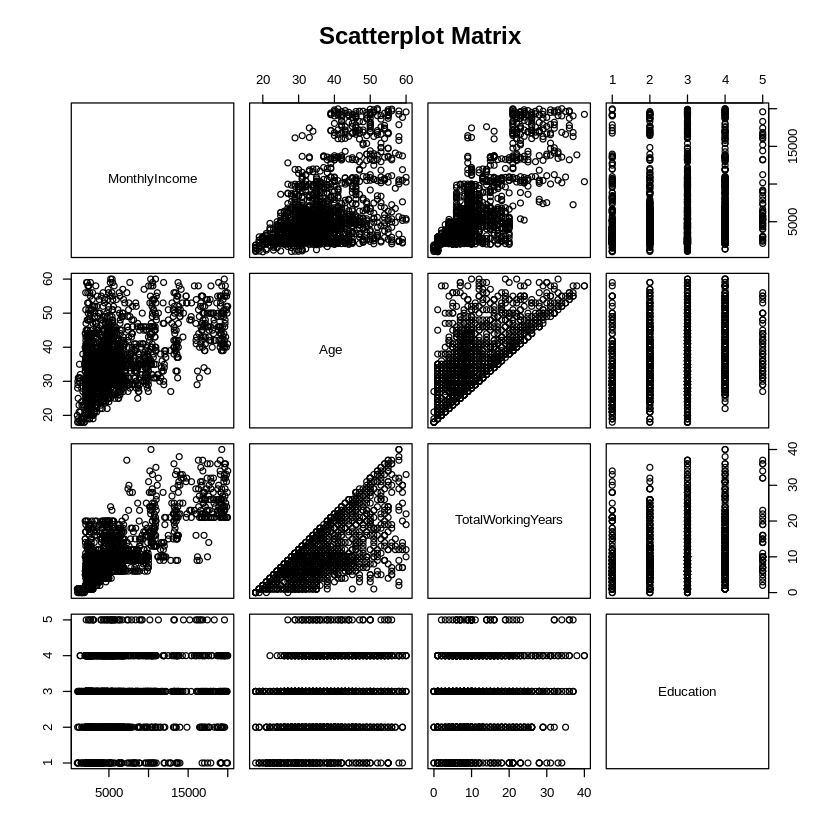

In [29]:
pairs(~MonthlyIncome+Age+TotalWorkingYears+Education, data = hrdata, main="Scatterplot Matrix")

In [32]:
cor(hrdata_numeric, method= "pearson")


Warning message in cor(hrdata_numeric, method = "pearson"):
“the standard deviation is zero”


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000000,0.0106609426,-0.001686120,0.208033731,NA,-0.010145467,0.010146428,0.024286543,0.029819959,0.509604228,⋯,0.0535347197,NA,0.037509712,0.680380536,-0.019620819,-0.021490028,0.311308770,0.212901056,0.216513368,0.2020886024
DailyRate,0.010660943,1.0000000000,-0.004985337,-0.016806433,NA,-0.050990434,0.018354854,0.023381422,0.046134874,0.002966335,⋯,0.0078460310,NA,0.042142796,0.014514739,0.002452543,-0.037848051,-0.034054768,0.009932015,-0.033228985,-0.0263631782
DistanceFromHome,-0.001686120,-0.0049853374,1.000000000,0.021041826,NA,0.032916407,-0.016075327,0.031130586,0.008783280,0.005302731,⋯,0.0065574746,NA,0.044871999,0.004628426,-0.036942234,-0.026556004,0.009507720,0.018844999,0.010028836,0.0144060484
Education,0.208033731,-0.0168064332,0.021041826,1.000000000,NA,0.042070093,-0.027128313,0.016774829,0.042437634,0.101588886,⋯,-0.0091183767,NA,0.018422220,0.148279697,-0.025100241,0.009819189,0.069113696,0.060235554,0.054254334,0.0690653783
EmployeeCount,NA,NA,NA,NA,1,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
EmployeeNumber,-0.010145467,-0.0509904337,0.032916407,0.042070093,NA,1.000000000,0.017620802,0.035179212,-0.006887923,-0.018519194,⋯,-0.0698614115,NA,0.062226693,-0.014365198,0.023603170,0.010308641,-0.011240464,-0.008416312,-0.009019064,-0.0091966453
EnvironmentSatisfaction,0.010146428,0.0183548543,-0.016075327,-0.027128313,NA,0.017620802,1.000000000,-0.049856956,-0.008277598,0.001211699,⋯,0.0076653835,NA,0.003432158,-0.002693070,-0.019359308,0.027627295,0.001457549,0.018007460,0.016193606,-0.0049987226
HourlyRate,0.024286543,0.0233814215,0.031130586,0.016774829,NA,0.035179212,-0.049856956,1.000000000,0.042860641,-0.027853486,⋯,0.0013304528,NA,0.050263399,-0.002333682,-0.008547685,-0.004607234,-0.019581616,-0.024106220,-0.026715586,-0.0201232002
JobInvolvement,0.029819959,0.0461348740,0.008783280,0.042437634,NA,-0.006887923,-0.008277598,0.042860641,1.000000000,-0.012629883,⋯,0.0342968206,NA,0.021522640,-0.005533182,-0.015337826,-0.014616593,-0.021355427,0.008716963,-0.024184292,0.0259758079
JobLevel,0.509604228,0.0029663349,0.005302731,0.101588886,NA,-0.018519194,0.001211699,-0.027853486,-0.012629883,1.000000000,⋯,0.0216415105,NA,0.013983911,0.782207805,-0.018190550,0.037817746,0.534738687,0.389446733,0.353885347,0.3752806078


In [36]:
# prompt: show me what cor is closer to 1, closer to -1, what column and row is it? give me the name of that value or itself

# Exclude columns with zero standard deviation
numeric_cols_for_cor <- hrdata_numeric[, sapply(hrdata_numeric, sd, na.rm = TRUE) != 0]

hrdata_cor <- cor(numeric_cols_for_cor, method = "pearson")

# Find the maximum absolute correlation (excluding the diagonal of 1s)
max_cor_abs <- max(abs(hrdata_cor[upper.tri(hrdata_cor)]))

# Find the minimum (most negative) correlation
min_cor <- min(hrdata_cor[upper.tri(hrdata_cor)])

# Find the correlation value closest to 1
cor_closest_to_1 <- max_cor_abs

# Find the correlation value closest to -1
cor_closest_to_neg1 <- min_cor

# Find the row and column names for the correlation closest to 1
max_loc <- which(abs(hrdata_cor) == max_cor_abs, arr.ind = TRUE)
row_name_closest_to_1 <- rownames(hrdata_cor)[max_loc[1, 1]]
col_name_closest_to_1 <- colnames(hrdata_cor)[max_loc[1, 2]]

# Find the row and column names for the correlation closest to -1
min_loc <- which(hrdata_cor == min_cor, arr.ind = TRUE)
row_name_closest_to_neg1 <- rownames(hrdata_cor)[min_loc[1, 1]]
col_name_closest_to_neg1 <- colnames(hrdata_cor)[min_loc[1, 2]]

cat("Correlation closest to 1:\n")
cat("  Value:", cor_closest_to_1, "\n")
cat("  Variables:", row_name_closest_to_1, "and", col_name_closest_to_1, "\n\n")

cat("Correlation closest to -1:\n")
cat("  Value:", cor_closest_to_neg1, "\n")
cat("  Variables:", row_name_closest_to_neg1, "and", col_name_closest_to_neg1, "\n")

Correlation closest to 1:
  Value: 0.9502999 
  Variables: MonthlyIncome and JobLevel 

Correlation closest to -1:
  Value: -0.1184213 
  Variables: YearsAtCompany and NumCompaniesWorked 


In [42]:
cor(hrdata_no_outliers, method= "pearson")

Warning message in cor(hrdata_no_outliers, method = "pearson"):
“the standard deviation is zero”


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,⋯,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
Age,1.000000000,0.0106609426,-0.001686120,0.208033731,NA,-0.010145467,0.010146428,0.024286543,0.029819959,0.509604228,⋯,0.0535347197,NA,0.037509712,0.680380536,-0.019620819,-0.021490028,0.311308770,0.212901056,0.216513368,0.2020886024
DailyRate,0.010660943,1.0000000000,-0.004985337,-0.016806433,NA,-0.050990434,0.018354854,0.023381422,0.046134874,0.002966335,⋯,0.0078460310,NA,0.042142796,0.014514739,0.002452543,-0.037848051,-0.034054768,0.009932015,-0.033228985,-0.0263631782
DistanceFromHome,-0.001686120,-0.0049853374,1.000000000,0.021041826,NA,0.032916407,-0.016075327,0.031130586,0.008783280,0.005302731,⋯,0.0065574746,NA,0.044871999,0.004628426,-0.036942234,-0.026556004,0.009507720,0.018844999,0.010028836,0.0144060484
Education,0.208033731,-0.0168064332,0.021041826,1.000000000,NA,0.042070093,-0.027128313,0.016774829,0.042437634,0.101588886,⋯,-0.0091183767,NA,0.018422220,0.148279697,-0.025100241,0.009819189,0.069113696,0.060235554,0.054254334,0.0690653783
EmployeeCount,NA,NA,NA,NA,1,NA,NA,NA,NA,NA,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
EmployeeNumber,-0.010145467,-0.0509904337,0.032916407,0.042070093,NA,1.000000000,0.017620802,0.035179212,-0.006887923,-0.018519194,⋯,-0.0698614115,NA,0.062226693,-0.014365198,0.023603170,0.010308641,-0.011240464,-0.008416312,-0.009019064,-0.0091966453
EnvironmentSatisfaction,0.010146428,0.0183548543,-0.016075327,-0.027128313,NA,0.017620802,1.000000000,-0.049856956,-0.008277598,0.001211699,⋯,0.0076653835,NA,0.003432158,-0.002693070,-0.019359308,0.027627295,0.001457549,0.018007460,0.016193606,-0.0049987226
HourlyRate,0.024286543,0.0233814215,0.031130586,0.016774829,NA,0.035179212,-0.049856956,1.000000000,0.042860641,-0.027853486,⋯,0.0013304528,NA,0.050263399,-0.002333682,-0.008547685,-0.004607234,-0.019581616,-0.024106220,-0.026715586,-0.0201232002
JobInvolvement,0.029819959,0.0461348740,0.008783280,0.042437634,NA,-0.006887923,-0.008277598,0.042860641,1.000000000,-0.012629883,⋯,0.0342968206,NA,0.021522640,-0.005533182,-0.015337826,-0.014616593,-0.021355427,0.008716963,-0.024184292,0.0259758079
JobLevel,0.509604228,0.0029663349,0.005302731,0.101588886,NA,-0.018519194,0.001211699,-0.027853486,-0.012629883,1.000000000,⋯,0.0216415105,NA,0.013983911,0.782207805,-0.018190550,0.037817746,0.534738687,0.389446733,0.353885347,0.3752806078


In [43]:
# prompt: using the just copied dataframe, show me what cor is closer to 1, closer to -1, what column and row is it? give me the name of that value or itself

# Exclude columns with zero standard deviation for the cleaned dataset
numeric_cols_cleaned <- hrdata_no_outliers[, sapply(hrdata_no_outliers, sd, na.rm = TRUE) != 0]

hrdata_cor_cleaned <- cor(numeric_cols_cleaned, method = "pearson")

# Find the maximum absolute correlation (excluding the diagonal of 1s) for cleaned data
max_cor_abs_cleaned <- max(abs(hrdata_cor_cleaned[upper.tri(hrdata_cor_cleaned)]))

# Find the minimum (most negative) correlation for cleaned data
min_cor_cleaned <- min(hrdata_cor_cleaned[upper.tri(hrdata_cor_cleaned)])

# Find the correlation value closest to 1 for cleaned data
cor_closest_to_1_cleaned <- max_cor_abs_cleaned

# Find the correlation value closest to -1 for cleaned data
cor_closest_to_neg1_cleaned <- min_cor_cleaned

# Find the row and column names for the correlation closest to 1 for cleaned data
max_loc_cleaned <- which(abs(hrdata_cor_cleaned) == max_cor_abs_cleaned, arr.ind = TRUE)
row_name_closest_to_1_cleaned <- rownames(hrdata_cor_cleaned)[max_loc_cleaned[1, 1]]
col_name_closest_to_1_cleaned <- colnames(hrdata_cor_cleaned)[max_loc_cleaned[1, 2]]

# Find the row and column names for the correlation closest to -1 for cleaned data
min_loc_cleaned <- which(hrdata_cor_cleaned == min_cor_cleaned, arr.ind = TRUE)
row_name_closest_to_neg1_cleaned <- rownames(hrdata_cor_cleaned)[min_loc_cleaned[1, 1]]
col_name_closest_to_neg1_cleaned <- colnames(hrdata_cor_cleaned)[min_loc_cleaned[1, 2]]

cat("\n--- Analysis on Dataframe with MonthlyIncome Outliers Removed ---\n\n")
cat("Correlation closest to 1:\n")
cat("  Value:", cor_closest_to_1_cleaned, "\n")
cat("  Variables:", row_name_closest_to_1_cleaned, "and", col_name_closest_to_1_cleaned, "\n\n")

cat("Correlation closest to -1:\n")
cat("  Value:", cor_closest_to_neg1_cleaned, "\n")
cat("  Variables:", row_name_closest_to_neg1_cleaned, "and", col_name_closest_to_neg1_cleaned, "\n")


--- Analysis on Dataframe with MonthlyIncome Outliers Removed ---

Correlation closest to 1:
  Value: 0.9502999 
  Variables: MonthlyIncome and JobLevel 

Correlation closest to -1:
  Value: -0.1184213 
  Variables: YearsAtCompany and NumCompaniesWorked 


##### Now we establish a dataframe named yes_age to analyze the age of employees who left the company, or say YES to attrition


In [44]:
yes_age <- hrdata[(hrdata$Attrition == "Yes"), 'Age']

Similarly, no_age is the df of employees who stayed and their age


In [46]:
no_age <- hrdata[(hrdata$Attrition != "Yes"), 'Age']

We conducted an independent samples t-test to compare the average ages of employees who left the company (Attrition = Yes) versus those who stayed (Attrition = No).

The null hypothesis assumes no difference in average age between the two groups. The alternative hypothesis suggests a difference exists.

At the 95% confidence level, a p-value below 0.05 would lead us to reject the null hypothesis in favor of the alternative.

In [47]:
t.test(yes_age, no_age)


	Welch Two Sample t-test

data:  yes_age and no_age
t = -5.828, df = 316.93, p-value = 1.38e-08
alternative hypothesis: true difference in means is not equal to 0
95 percent confidence interval:
 -5.288346 -2.618930
sample estimates:
mean of x mean of y 
 33.60759  37.56123 


###
There is a statistically significant difference in the average ages between the two groups (yes_age and no_age), with a p-value of 1.38e-08, which is far below the typical alpha level of 0.05.

The mean age for the yes group is 33.6, who left the company- their mean age is 33.6, while for the no group it is 37.56.

The 95% confidence interval for the difference in means is [-5.29, -2.62], meaning we are 95% confident the true difference in means lies between -5.29 and -2.62 years.

Since the confidence interval does not include 0 and is entirely negative, it confirms that the yes group is, on average, younger than the no group.
As an HR Generalist, I would layout score cards based on this question: Has this candidate — regardless of age — demonstrated commitment, stability, or alignment with the role’s long-term demands?
-> Look at prior job tenures.
-> Ask behavioral questions around work expectations and commitment.
-> Evaluate life and career stage alignment, without making assumptions purely based on age.

This is represented by the below boxplot as well.

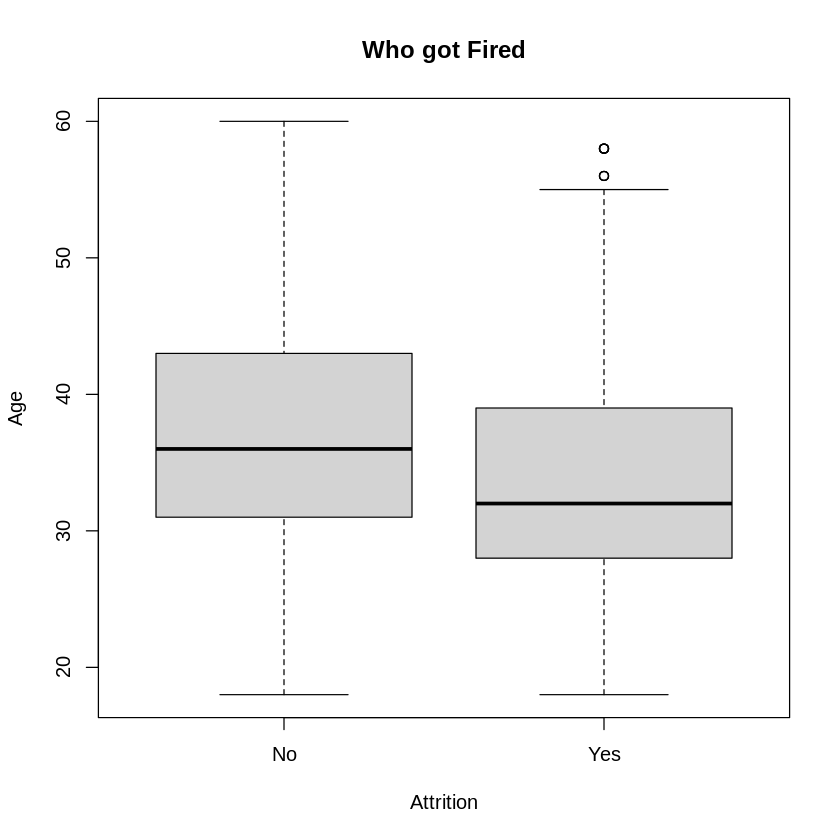

In [49]:
boxplot(Age ~ Attrition , data = hrdata, main ="Left", xlab = "Attrition", ylab= "Age")

And we have to look at their compensation:

p value is larger than our threshold level. Thus, we fail to reject null hypothesis the mean age of two groups who left are not different from each tother.

In [ ]:
model1 = lm(MonthlyIncome ~ Age, data = hrdata)
summary(model1)

In [ ]:
model2 = lm(MonthlyIncome ~ Age + TotalWorkingYears, data= hrdata)
summary(model2)

Side note

In [ ]:
install.packages("googledrive")
library(googledrive)

Once the package is installed and loaded, you can use the `drive_auth()` function to authenticate and mount your Google Drive.

After authentication, you can use `drive_find()` to locate your file and `drive_download()` to download it to your Colab environment for use in your R code. For example, if your file is in the root of your Drive, you can find and download it like this:

In [ ]:
drive_auth()

In [ ]:
# Find the file in your Drive
file_info <- drive_find(pattern = "hr.csv.csv", n_max = 1)

# Download the file to the current directory
drive_download(file_info$id, overwrite = TRUE)